**_note: this Notebook has been run with an existing file and a chosen featurizer option, so that there are outputs that you can read. You won't be able to run it yourself as-is because there are now placeholders for the file path and the featurizer function_**

# Code loading

Load all the stuff necessary:

In [30]:
using DrWatson
@quickactivate "ComplexMultistability"
include(srcdir("data_loading.jl"))
include(srcdir("clustering", "clustering_api.jl"))
include(srcdir("optimization", "optimization_api.jl"))
include(srcdir("intermingledness.jl"));

# INPUTS: you must provide these

### 1: path to your file

In [32]:
file = "path/to/your/file.nc";

### 2: the featurizer function

Here we provide a sample featurizer that returns the standard deviation of last 4th of timeseries, for _all_ diagnostic variables.

In [3]:
using Statistics: std
function featurizer(A::StateSpaceSet, t)
    cols = columns(A)
    L = length(A)
    Ls = round(Int, 0.75L)
    features = map(c -> std(c[Ls:L]), cols)
    return SVector(features) # recommended to return `SVector`
end

featurizer (generic function with 1 method)

# Optimization
the rest of the code "works"
but please see the rest of files in `/scripts` for examples

load

In [4]:
X = ncread(file, "value") # or whatever other name you have named your data
diagnostics = gnv(dims(X, Diagnostic))
ics = gnv(dims(X, InitCond))
t = gnv(dims(X, Tim))
allfeatures = cast_to_features(X, featurizer)
allfeatures01 = rescale_to_01(allfeatures) # this saves computational effort
allfeatures01[1:10] # show only a few features in the notebook

┌ Warning: Dimension name "diagnostic" not in common names.
│ Please consider opening an issue/PR on GitHub proposing "diagnostic" in common names!
│ Making a generic dimension named `Dim{:diagnostic}` for now...
└ @ ClimateBase C:\Users\datse\.julia\packages\ClimateBase\N5dG5\src\io\netcdf_read.jl:178
┌ Warning: Dimension name "ic" not in common names.
│ Please consider opening an issue/PR on GitHub proposing "ic" in common names!
│ Making a generic dimension named `Dim{:ic}` for now...
└ @ ClimateBase C:\Users\datse\.julia\packages\ClimateBase\N5dG5\src\io\netcdf_read.jl:178


38-dimensional StateSpaceSet{Float64} with 10 points
 0.27507    0.527309   0.521348   …  0.94454    0.235381   0.120734
 0.0325988  0.984476   0.978805      0.0210698  0.0368409  0.0483287
 0.0429987  0.984968   0.990443      0.0192997  0.0285212  0.0586253
 0.0357847  0.983905   0.981716      0.0262808  0.0415487  0.0403369
 1.0        0.0398382  0.0336204     0.513565   0.954986   0.947241
 0.0194217  0.989401   0.993568   …  0.0226473  0.0186274  0.03088
 0.0343615  0.988129   0.987824      0.0184126  0.0137798  0.0196884
 0.0189434  0.987507   0.995011      0.0290121  0.0445396  0.022702
 0.330049   0.494284   0.492489      0.987504   0.148429   0.046644
 0.895862   0.0275914  0.0102638     0.504161   0.956328   0.916078

set up clustering options (you can alter these)

In [5]:
ca = ADBSCAN(; rescale_features = false, min_neighbors = 10);

set up clustering quality options (you can alter these)

In [6]:
fcq = FeaturesClusteringQuality(; attractor_weight = 1.0, feature_weight = 0.5, ca);

perform the optimization loop (you can alter the keywords)

In [ ]:
best_choice, best_labels = optimize_feature_selection(fcq, allfeatures01;
    verbose = false, minF = 2, reclustering = 0,
);

BruteForce Clustering... 100%|███████████████████████████| Time: 0:00:25


2-element Vector{Int64}:
  3
 27

These are the found attractors

In [18]:
natt = length(unique(best_labels))

3

These are the diagnostics features that optimized the grouping:

In [19]:
best_choice

2-element Vector{Int64}:
  3
 27

we also create now the basins of attraction (however this makes sense for you)

In [16]:
u0s = initial_conditions(X)
u0s[1:10]

38-dimensional StateSpaceSet{Float64} with 10 points
 0.1  0.00810603   0.00818342   …  0.00797449   0.00646313  0.00370466
 0.1  0.000685718  0.00840096      0.00631787   0.00820975  0.00565667
 0.1  0.00683386   0.00531528      0.000560114  0.00310433  0.00146375
 0.1  0.000448529  0.000696653     0.00340498   0.00382107  0.0037052
 0.1  0.00553142   0.000924322     0.000304928  0.00322027  0.00459061
 0.1  0.000502838  0.00662935   …  0.00299438   0.00471158  0.00276992
 0.1  0.00761473   0.0030108       0.00105279   0.00493581  0.0013646
 0.1  0.00631486   0.00795423      0.00383885   0.00781851  0.00327336
 0.1  0.00173687   0.00139652      0.00961685   0.00099652  0.00381955
 0.1  0.00661266   0.00958706      0.00674284   0.00344246  0.00238192

# Intermingledness

In [17]:
imatrix_features = intermingledness(allfeatures, best_labels)
imatrix_basins = intermingledness(u0s, best_labels)

3×38 Matrix{Float64}:
 0.968182  1.04265   0.982536  1.01272   …  1.04507   1.02335   0.98461
 1.02512   1.1202    0.960129  1.0189       1.06437   1.02399   1.00045
 1.05573   0.782449  1.04549   0.967727     0.906455  0.813619  0.973869

# Characteristic plots

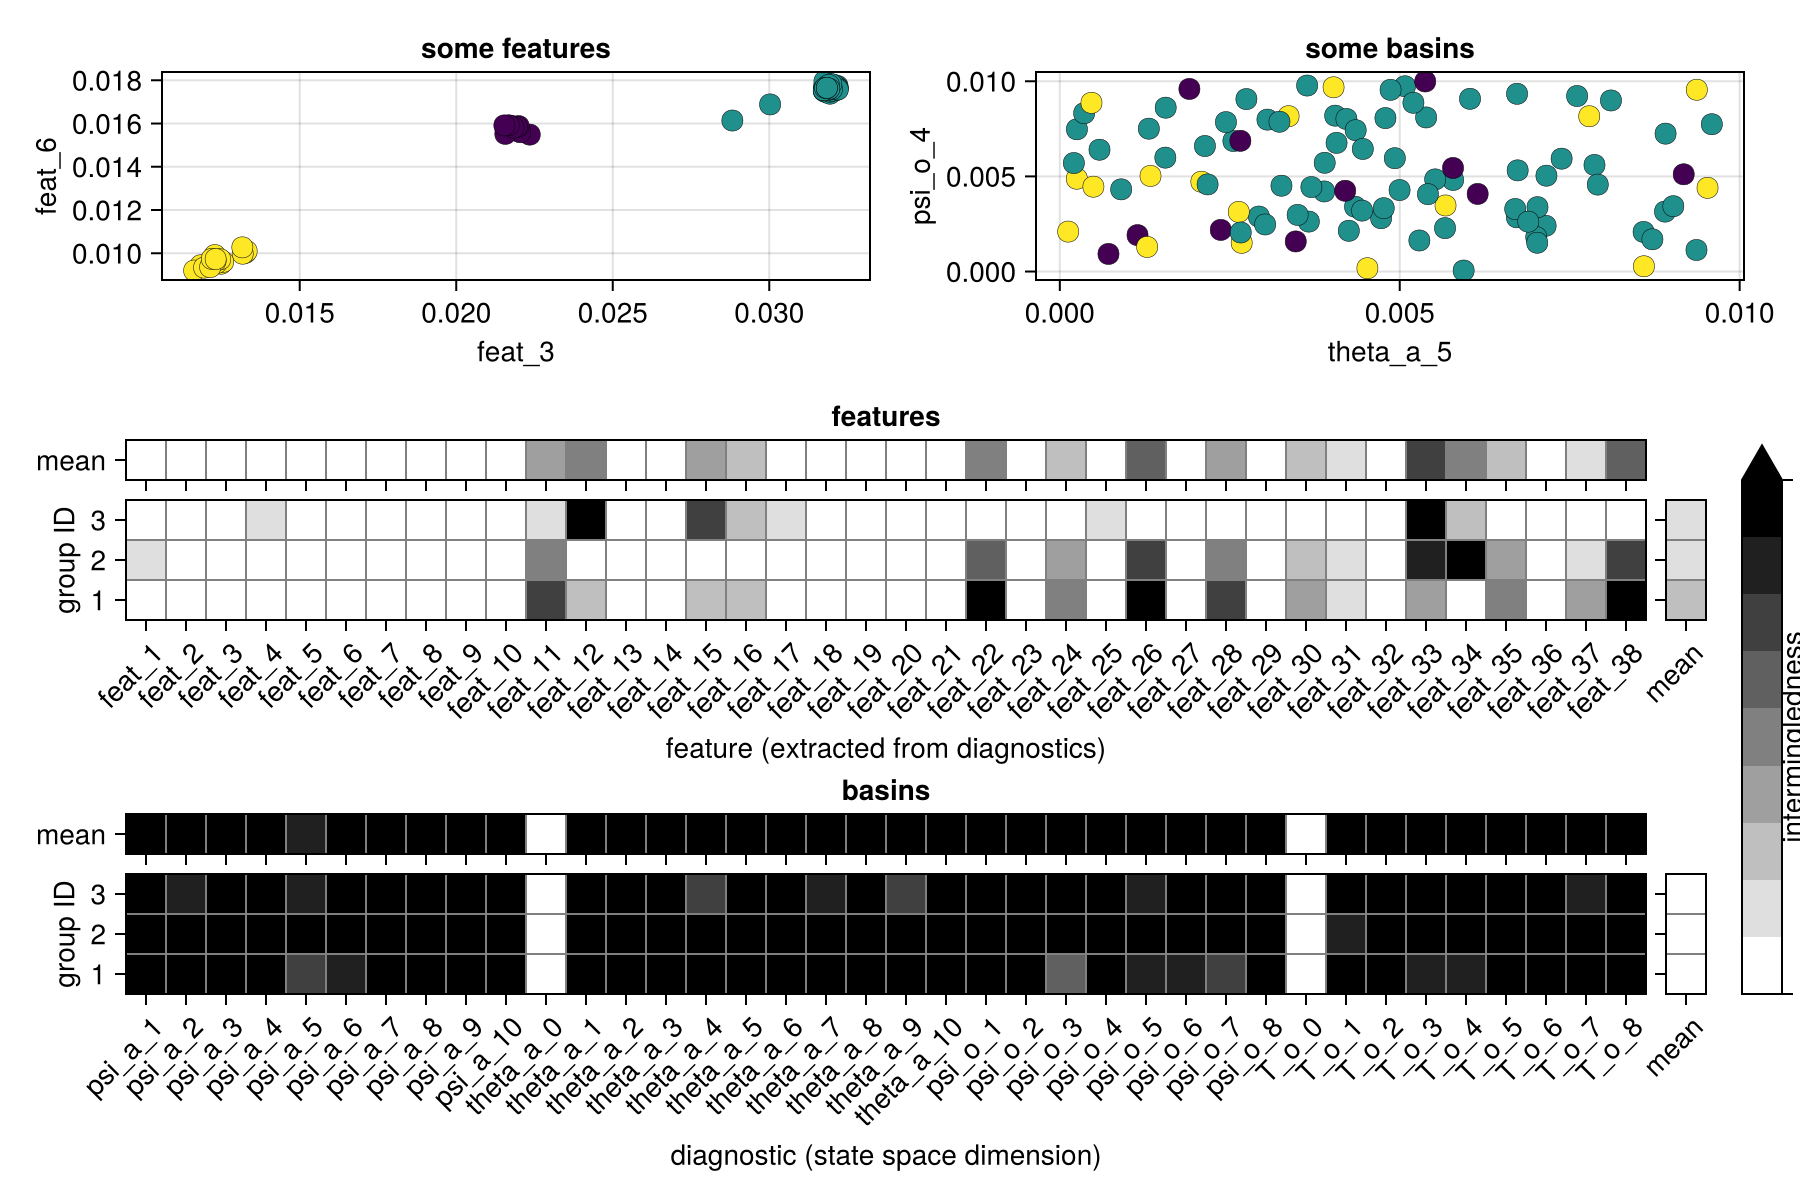

In [31]:
fig = Figure(size = (900, 600))
# you likely want to change this:
feature_names = ["feat_$(i)" for i in 1:dimension(allfeatures)]

# features and basins
gl1 = GridLayout(fig[1,1])
axf = Axis(gl1[1,1]; title = "some features")
axb = Axis(gl1[1,2]; title = "some basins")

for (ax, set, names) in zip((axf, axb), (allfeatures, u0s), (feature_names, diagnostics))
    cols = columns(set)
    i, j = sample(1:dimension(set), 2; replace = false)
    scatter!(ax, cols[i], cols[j];
        color = best_labels, markersize = 15, strokewidth = 0.25, strokecolor = "black",
    )
    ax.xlabel = names[i]
    ax.ylabel = names[j]
end

intermingledness
gl2 = GridLayout(fig[2,1]; tellwidth = false)
plot_twice_intermingledness!(gl2, imatrix_features, imatrix_basins,;
    title1 = "features", title2 = "basins",
    names = feature_names,
    names2 = diagnostics, unitlen = 20, fixed_size = true,
)

fig